# GC/MS metabolite analysis — combined runs + replicated original workflow

This notebook combines the **original analysis workflow** with the newer **pooled/QC workflow**.

## Dataset decisions

- Run 1 and Run 2 biological replicates are pooled.
- The repeated `_1` samples at the end of the Run 2 Summary sheet are treated as **technical reruns** and averaged with their corresponding first biological sample.
- Final biological n:
  - Control = **6**
  - FPM IC25 = **3**
  - FPM IC50 = **5**
  - SRM IC25 = **5**
  - SRM IC50 = **5**
- Known aliases are harmonized:
  - `2HG` → `2Hydroxyglutarate`
  - `3PG` → `3Phosphoglycerate`
  - `PEP` → `Penolpyruvate`
- Primary pooled analyses use only metabolites measured in **both runs**.
- Run-specific metabolites remain separate:
  - Run 1 only: `4OHBenzoate`
  - Run 2 only: `Cystine`, `Histidine`, `Quinolinate`, `Serotonin`
- Cell-count/viability data are shown as **QC only** and are not used to normalize GC/MS abundance.

## Analysis sections

This notebook reproduces the major analyses from the original notebook:
1. pooled means and standard deviations
2. clustered log₂ fold-change heatmap
3. pairwise Welch tests + FDR
4. top p-value and q-value plots
5. sample-size summary
6. 1.2-fold-change heatmap
7. gated significance plots
8. FPM-only long-format analysis
9. top-10 impacted metabolites
10. 1.2-fold-gated FPM dot plots
11. p-value-filtered FPM plots
12. final landscape fold-change plot
13. QC and export tables

In [1]:
%pip install matplotlib seaborn scipy statsmodels openpyxl

In [2]:
%config InlineBackend.figure_format = "retina"

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

sns.set(style="white", context="talk")

OLD_FILE = "nmols_metabolites.csv"
NEW_FILE = "Madeline Vera-Colon (Sparks lab UCI) polar quant 20260911.xlsx"
COUNT_FILE = "d7_MetaboliteCounts.xlsx"

alias_map = {
    "2HG": "2Hydroxyglutarate",
    "3PG": "3Phosphoglycerate",
    "PEP": "Penolpyruvate",
}

## 1. Load and combine Run 1 + Run 2

In [3]:
# -----------------------------
# Run 1
# -----------------------------
run1_raw = (
    pd.read_csv(OLD_FILE)
    .rename(columns={"Unnamed: 0": "Metabolites"})
    .set_index("Metabolites")
)

run1_raw = run1_raw.replace({
    "#VALUE!": np.nan,
    "#DIV/0!": np.nan,
    "": np.nan,
}).apply(pd.to_numeric, errors="coerce")

run1_column_map = {
    "Control_1_1": "Run1_Control_1",
    "Control_2_2": "Run1_Control_2",
    "Control_3_3": "Run1_Control_3",

    "FPM_low_1_4": "Run1_FPM_IC25_1",
    "FPM_low_2_5": "Run1_FPM_IC25_2",
    "FPM_low_3_6": "Run1_FPM_IC25_3",

    "FPM_1.4_1_7": "Run1_FPM_IC50_1",
    "FPM_1.4_2_8": "Run1_FPM_IC50_2",

    "SRM_low_1_13": "Run1_SRM_IC25_1",
    "SRM_low_2_14": "Run1_SRM_IC25_2",

    "SRM_5.9_1_16": "Run1_SRM_IC50_1",
    "SRM_5.9_2_17": "Run1_SRM_IC50_2",
}

run1 = run1_raw[list(run1_column_map)].rename(columns=run1_column_map)

# -----------------------------
# Run 2
# -----------------------------
summary = pd.read_excel(NEW_FILE, sheet_name="Summary", header=None)

run2_values = summary.iloc[3:, 1:17].apply(pd.to_numeric, errors="coerce")
run2_values.index = summary.iloc[3:, 0].astype(str)
run2_values.index.name = "Metabolites"

run2_values.index = [
    alias_map.get(name, name)
    for name in run2_values.index
]

run2 = pd.DataFrame(index=run2_values.index)

# Biological replicate 1 = mean of original measurement + technical rerun
run2["Run2_Control_1"] = run2_values.iloc[:, [0, 12]].mean(axis=1, skipna=True)
run2["Run2_FPM_IC50_1"] = run2_values.iloc[:, [1, 13]].mean(axis=1, skipna=True)
run2["Run2_SRM_IC25_1"] = run2_values.iloc[:, [2, 14]].mean(axis=1, skipna=True)
run2["Run2_SRM_IC50_1"] = run2_values.iloc[:, [3, 15]].mean(axis=1, skipna=True)

run2["Run2_Control_2"] = run2_values.iloc[:, 4]
run2["Run2_FPM_IC50_2"] = run2_values.iloc[:, 5]
run2["Run2_SRM_IC25_2"] = run2_values.iloc[:, 6]
run2["Run2_SRM_IC50_2"] = run2_values.iloc[:, 7]

run2["Run2_Control_3"] = run2_values.iloc[:, 8]
run2["Run2_FPM_IC50_3"] = run2_values.iloc[:, 9]
run2["Run2_SRM_IC25_3"] = run2_values.iloc[:, 10]
run2["Run2_SRM_IC50_3"] = run2_values.iloc[:, 11]

# -----------------------------
# Shared vs run-specific analytes
# -----------------------------
shared_metabolites = sorted(set(run1.index) & set(run2.index))
run1_only_metabolites = sorted(set(run1.index) - set(run2.index))
run2_only_metabolites = sorted(set(run2.index) - set(run1.index))

combined_all = pd.concat([run1, run2], axis=1, join="outer")
combined_all.index.name = "Metabolites"

# Primary matrix used for pooled statistics
pooled_df = combined_all.loc[shared_metabolites].copy()

# Compatibility names used by the original notebook
df_clean = pooled_df.copy()
df_excluded = pooled_df.copy()
df = pooled_df.reset_index()

groups_stats = {
    "Control": [
        "Run1_Control_1", "Run1_Control_2", "Run1_Control_3",
        "Run2_Control_1", "Run2_Control_2", "Run2_Control_3",
    ],
    "FPM_low": [
        "Run1_FPM_IC25_1", "Run1_FPM_IC25_2", "Run1_FPM_IC25_3",
    ],
    "FPM_1.4": [
        "Run1_FPM_IC50_1", "Run1_FPM_IC50_2",
        "Run2_FPM_IC50_1", "Run2_FPM_IC50_2", "Run2_FPM_IC50_3",
    ],
    "SRM_low": [
        "Run1_SRM_IC25_1", "Run1_SRM_IC25_2",
        "Run2_SRM_IC25_1", "Run2_SRM_IC25_2", "Run2_SRM_IC25_3",
    ],
    "SRM_5.9": [
        "Run1_SRM_IC50_1", "Run1_SRM_IC50_2",
        "Run2_SRM_IC50_1", "Run2_SRM_IC50_2", "Run2_SRM_IC50_3",
    ],
}

groups = groups_stats.copy()

sample_metadata = pd.DataFrame([
    {
        "Sample": sample,
        "Treatment": treatment,
        "Batch": "Run1" if sample.startswith("Run1_") else "Run2",
    }
    for treatment, samples in groups_stats.items()
    for sample in samples
])

print("Shared metabolites:", len(shared_metabolites))
print("Run 1 only:", run1_only_metabolites)
print("Run 2 only:", run2_only_metabolites)
print("\nFinal biological n:")
display(sample_metadata.groupby("Treatment").size().rename("n").to_frame())

Shared metabolites: 62
Run 1 only: ['4OHBenzoate']
Run 2 only: ['Cystine', 'Histidine', 'Quinolinate', 'Serotonin']

Final biological n:


C:\Users\mkmve\anaconda3\lib\site-packages\ipykernel_launcher.py:76: FutureWarning: Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.



,n
Treatment,
Control,6
FPM_1.4,5
FPM_low,3
SRM_5.9,5
SRM_low,5


## 2. QC: technical replicate reproducibility

In [4]:
technical_pairs = {
    "Control_1": (0, 12),
    "FPM_IC50_1": (1, 13),
    "SRM_IC25_1": (2, 14),
    "SRM_IC50_1": (3, 15),
}

technical_qc = []

for sample, (a_col, b_col) in technical_pairs.items():
    a = run2_values.iloc[:, a_col]
    b = run2_values.iloc[:, b_col]
    denom = pd.concat([a.abs(), b.abs()], axis=1).mean(axis=1)
    relative_difference = (a - b).abs() / denom.replace(0, np.nan)

    technical_qc.append({
        "Sample": sample,
        "Median relative difference": relative_difference.median(skipna=True),
        "Mean relative difference": relative_difference.mean(skipna=True),
        "Metabolites compared": relative_difference.notna().sum(),
    })

technical_qc = pd.DataFrame(technical_qc)
display(technical_qc)

,Mean relative difference,Median relative difference,Metabolites compared,Sample
0,0.181506,0.090731,66,Control_1
1,0.120221,0.063605,66,FPM_IC50_1
2,0.112177,0.047852,66,SRM_IC25_1
3,0.101529,0.057262,66,SRM_IC50_1


## 3. QC: cell-count and viability data (not used for normalization)

In [5]:
counts_raw = pd.read_excel(COUNT_FILE, header=None)

cell_qc = counts_raw.iloc[1:, 1:7].copy()
cell_qc.columns = ["Sample ID", "counts", "live", "dead", "total", "% viability"]

for col in ["counts", "live", "dead", "total", "% viability"]:
    cell_qc[col] = pd.to_numeric(cell_qc[col], errors="coerce")

cell_qc = cell_qc.dropna(subset=["Sample ID"]).reset_index(drop=True)

display(cell_qc)

print(
    "These values are shown as independent QC only and are not used "
    "to normalize sample-level metabolite abundance."
)

,Sample ID,counts,live,dead,total,% viability
0,Sample ID,NaN,NaN,NaN,NaN,NaN
1,Ctl,237.0,1390000.0,1.083600e+00,2470000.0,56.4
2,FPM IC25,242.0,1420000.0,1.380000e+06,2800000.0,50.8
3,FPM IC50,468.0,2750000.0,1.210000e+06,3960000.0,69.4
4,FPM 50,556.0,3270000.0,1.170000e+06,4440000.0,73.6
5,SRM IC25,242.0,1420000.0,1.490000e+06,2920000.0,48.8
6,SRM IC50,318.0,1870000.0,7.990000e+05,2670000.0,70.0
7,SRM 50,186.0,1090000.0,7.520000e+05,1850000.0,59.2


These values are shown as independent QC only and are not used to normalize sample-level metabolite abundance.


## 4. Replicated original analysis: group averages and standard deviations

In [6]:
avg_df = pd.DataFrame(index=df_excluded.index)
std_df = pd.DataFrame(index=df_excluded.index)

for condition, cols in groups.items():
    available_cols = [c for c in cols if c in df_excluded.columns]

    avg_df[condition] = df_excluded[available_cols].mean(axis=1, skipna=True)
    std_df[condition] = df_excluded[available_cols].std(axis=1, skipna=True, ddof=1)

summary_df = pd.concat(
    {"Averages": avg_df, "Std dev": std_df},
    axis=1
)

display(summary_df.head())

Averages                                              \
                     Control    FPM_low    FPM_1.4    SRM_low    SRM_5.9   
Metabolites                                                                
2Aminobutyrate      0.078643   0.068401   0.081391   0.092559   0.081127   
2Hydroxyglutarate   0.039634   0.051399   0.051397   0.054284   0.050211   
3-Hydroxybutyrate   0.030397   0.048400   0.040389   0.042548   0.038382   
3Phosphoglycerate   0.605715   1.830462   1.116371   0.766510   0.918624   
Alanine            17.139648  12.504414  18.422220  23.741301  18.142765   

                    Std dev                                          
                    Control   FPM_low   FPM_1.4   SRM_low   SRM_5.9  
Metabolites                                                          
2Aminobutyrate     0.024392  0.008810  0.020297  0.022070  0.030349  
2Hydroxyglutarate  0.009453  0.007735  0.017276  0.008466  0.022172  
3-Hydroxybutyrate  0.007335  0.001275  0.008045  0.008006  0.012539  
3Phosphoglycerate  0.144090  0.274808  0.588843  0.213489  0.384452  
Alanine            8.881957  2.531563  7.478274  9.750683  8.650881

## 5. Replicated original analysis: clustered log₂ fold-change heatmap

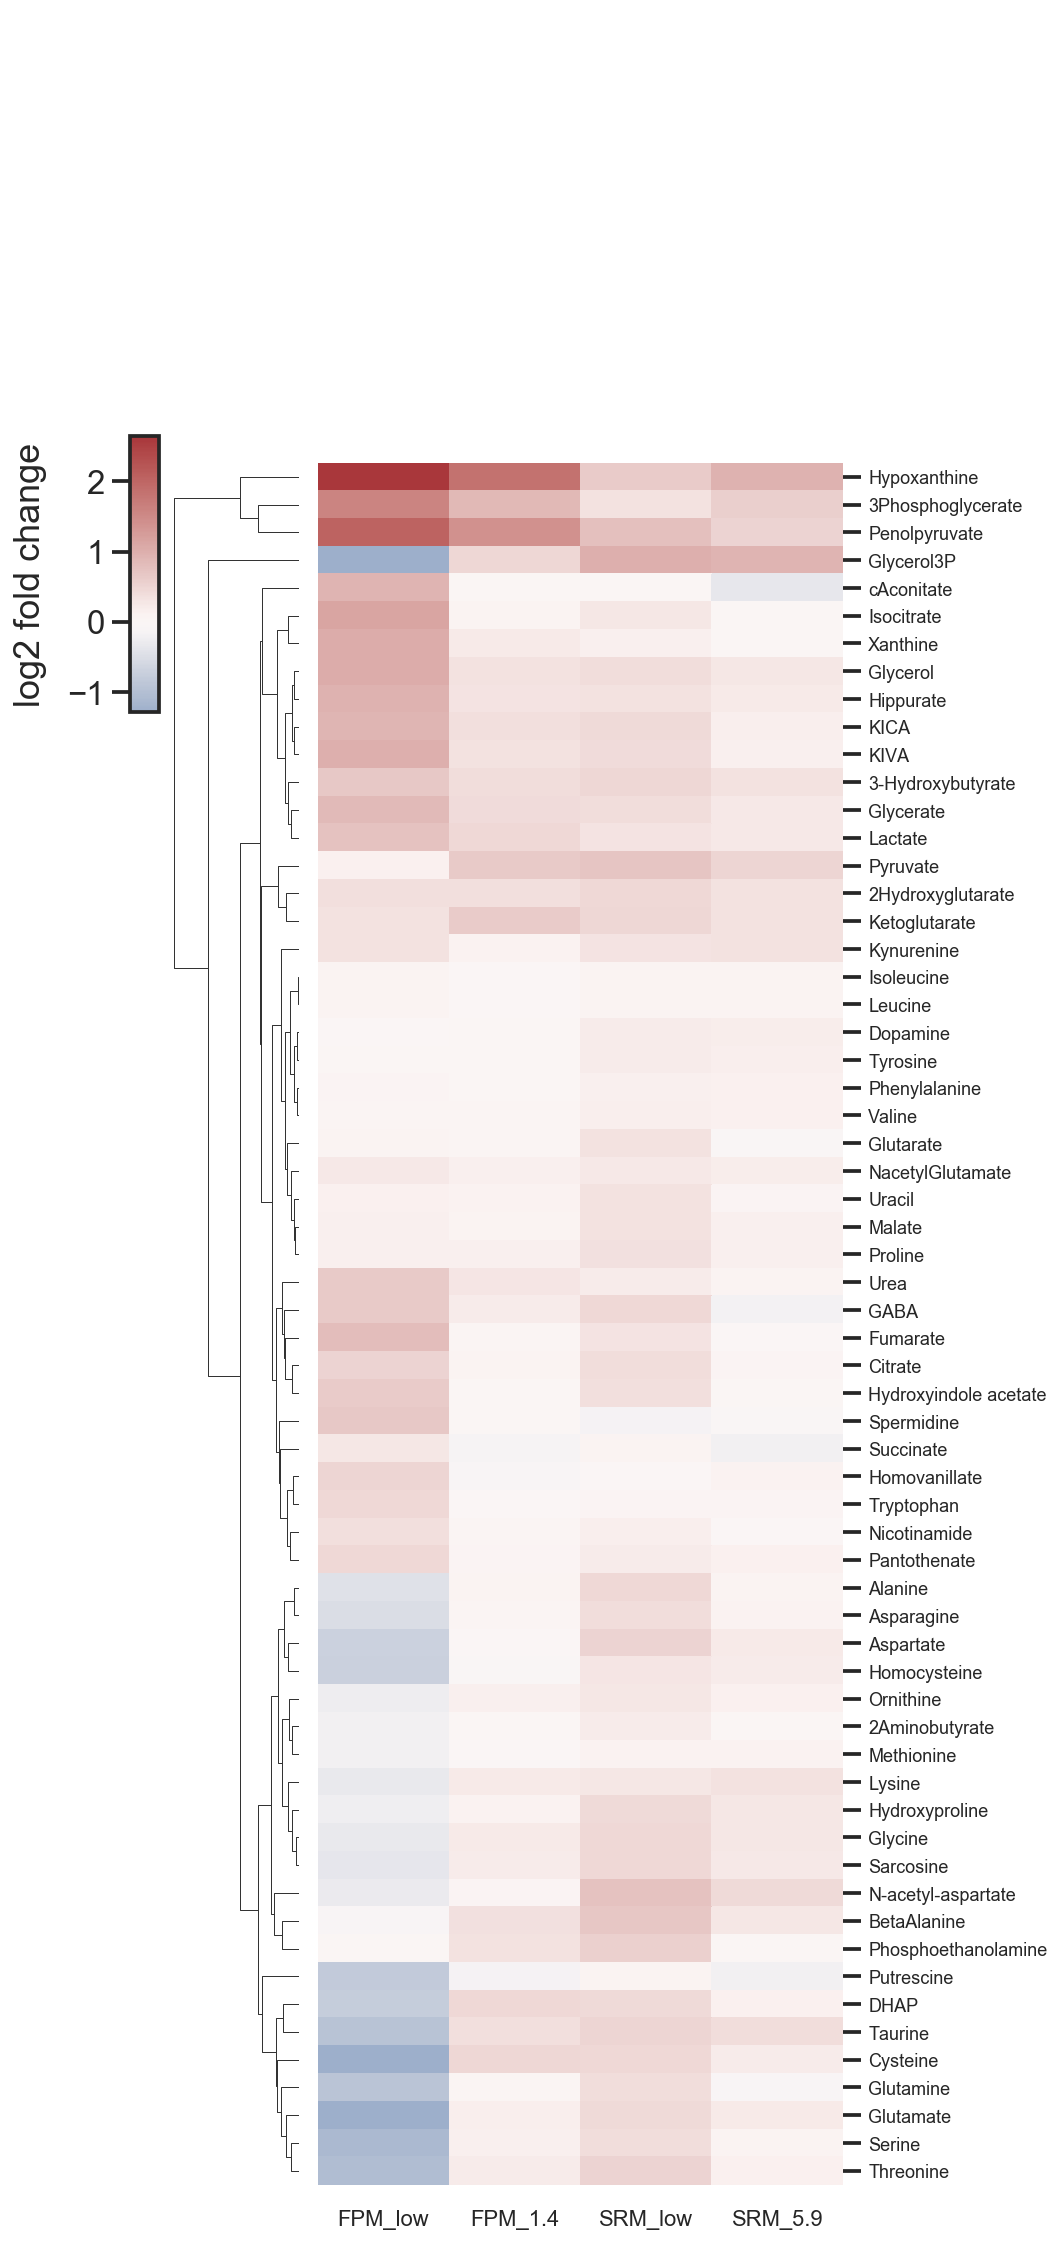

In [7]:
avg_clust = summary_df["Averages"].copy()
avg_clust = avg_clust.dropna(axis=0, how="any")

avg_fc = np.log2(avg_clust.div(avg_clust["Control"], axis=0))
avg_fc_plot = avg_fc.drop("Control", axis=1)

g = sns.clustermap(
    avg_fc_plot,
    cmap="vlag",
    center=0,
    figsize=(8, 16),
    xticklabels=True,
    yticklabels=True,
    method="average",
    metric="euclidean",
    row_cluster=True,
    col_cluster=False,
    cbar_pos=None,
)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=9)
g.ax_heatmap.tick_params(axis="x", labelsize=11)

cbar_ax = g.fig.add_axes([0.001, 0.68, 0.025, 0.12])
mappable = g.ax_heatmap.collections[0]
cbar = g.fig.colorbar(mappable, cax=cbar_ax)
cbar.set_label("log2 fold change", rotation=90, labelpad=10)
cbar_ax.yaxis.set_ticks_position("left")
cbar_ax.yaxis.set_label_position("left")

plt.show()

## 6. Replicated original analysis: pairwise Welch tests and FDR

In [8]:
control_cols = groups_stats["Control"]
results = []
epsilon = 1e-6

for treatment, treat_cols in groups_stats.items():
    if treatment == "Control":
        continue

    for metabolite in df_excluded.index:
        control_vals = df_excluded.loc[metabolite, control_cols].dropna().astype(float)
        treat_vals = df_excluded.loc[metabolite, treat_cols].dropna().astype(float)

        if len(control_vals) < 2 or len(treat_vals) < 2:
            continue

        control_log = np.log2(control_vals + epsilon)
        treat_log = np.log2(treat_vals + epsilon)

        stat, pval = ttest_ind(
            treat_log,
            control_log,
            equal_var=False,
            nan_policy="omit",
        )

        control_mean = control_vals.mean()
        treat_mean = treat_vals.mean()
        log2fc = np.log2(
            (treat_mean + epsilon) /
            (control_mean + epsilon)
        )

        results.append({
            "Metabolite": metabolite,
            "Comparison": f"{treatment}_vs_Control",
            "Treatment": treatment,
            "Control_mean": control_mean,
            "Treatment_mean": treat_mean,
            "log2FC": log2fc,
            "pvalue": pval,
            "n_control": len(control_vals),
            "n_treatment": len(treat_vals),
        })

pairwise_df = pd.DataFrame(results).dropna(subset=["pvalue"]).copy()
pairwise_df["qvalue"] = np.nan

for comparison in pairwise_df["Comparison"].unique():
    mask = pairwise_df["Comparison"] == comparison
    pairwise_df.loc[mask, "qvalue"] = multipletests(
        pairwise_df.loc[mask, "pvalue"],
        method="fdr_bh",
    )[1]

pairwise_df["neg_log10_pvalue"] = -np.log10(
    pairwise_df["pvalue"].clip(lower=1e-300)
)
pairwise_df["abs_log2FC"] = pairwise_df["log2FC"].abs()

pairwise_df = pairwise_df.sort_values(
    ["Comparison", "qvalue", "pvalue", "abs_log2FC"],
    ascending=[True, True, True, False],
)

display(pairwise_df.head(20))

,Comparison,Control_mean,Metabolite,Treatment,Treatment_mean,log2FC,n_control,n_treatment,pvalue,qvalue,neg_log10_pvalue,abs_log2FC
93,FPM_1.4_vs_Control,0.624297,Ketoglutarate,FPM_1.4,0.966680,0.630805,6,5,0.049907,0.992067,1.301841,0.630805
64,FPM_1.4_vs_Control,0.030397,3-Hydroxybutyrate,FPM_1.4,0.040389,0.410027,6,5,0.065050,0.992067,1.186756,0.410027
65,FPM_1.4_vs_Control,0.605715,3Phosphoglycerate,FPM_1.4,1.116371,0.882104,6,5,0.100447,0.992067,0.998062,0.882104
79,FPM_1.4_vs_Control,0.068006,Glycerate,FPM_1.4,0.091586,0.429462,6,5,0.128113,0.992067,0.892405,0.429462
105,FPM_1.4_vs_Control,0.119498,Penolpyruvate,FPM_1.4,0.316657,1.405922,6,5,0.145557,0.992067,0.836966,1.405922
63,FPM_1.4_vs_Control,0.039634,2Hydroxyglutarate,FPM_1.4,0.051397,0.374930,6,5,0.165651,0.992067,0.780806,0.374930
69,FPM_1.4_vs_Control,1.209815,BetaAlanine,FPM_1.4,1.562413,0.368989,6,5,0.229816,0.992067,0.638620,0.368989
107,FPM_1.4_vs_Control,4.160405,Phosphoethanolamine,FPM_1.4,5.224748,0.328637,6,5,0.251623,0.992067,0.599249,0.328637
95,FPM_1.4_vs_Control,44.858465,Lactate,FPM_1.4,61.635602,0.458384,6,5,0.287979,0.992067,0.540639,0.458384
92,FPM_1.4_vs_Control,0.078899,KIVA,FPM_1.4,0.100476,0.348772,6,5,0.400000,0.992067,0.397940,0.348772


## 7. Replicated original analysis: top metabolites by q-value and p-value

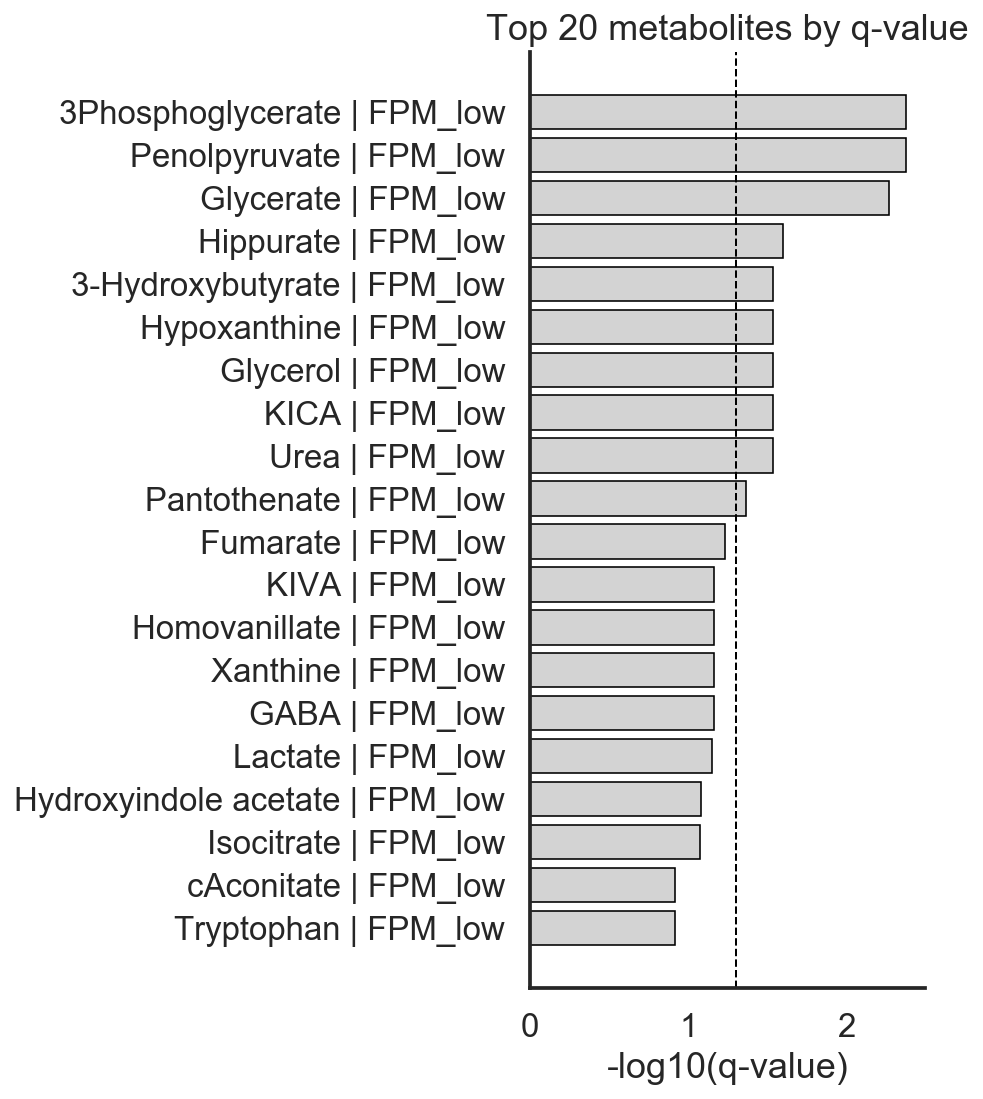

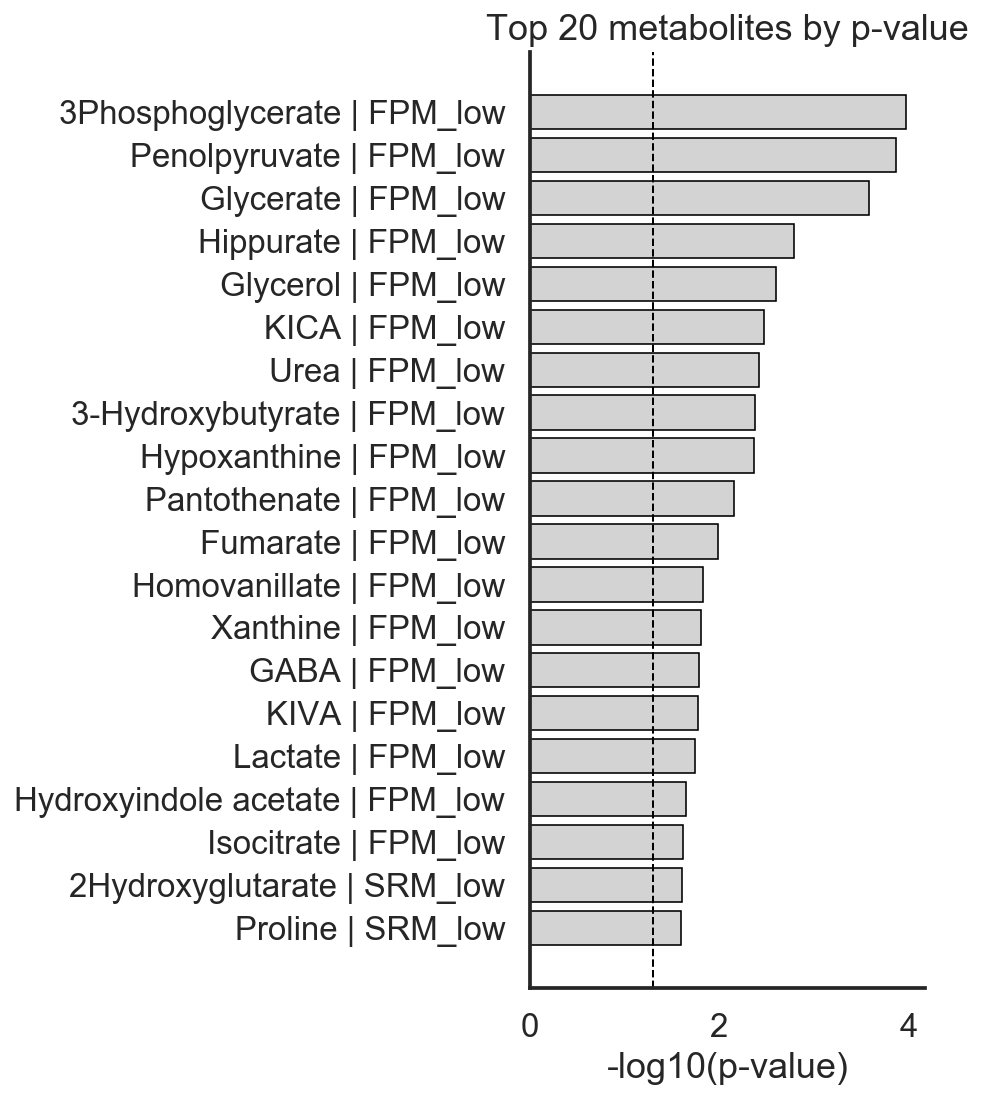

In [9]:
top_n = 20
epsilon_p = 1e-300

plot_df = pairwise_df.copy()
plot_df["neg_log10_qvalue"] = -np.log10(
    plot_df["qvalue"].clip(lower=epsilon_p)
)
plot_df["neg_log10_pvalue"] = -np.log10(
    plot_df["pvalue"].clip(lower=epsilon_p)
)
plot_df["Label"] = (
    plot_df["Metabolite"] + " | " + plot_df["Treatment"]
)

top_q = (
    plot_df
    .sort_values("qvalue", ascending=True)
    .head(top_n)
    .sort_values("neg_log10_qvalue", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(
    top_q["Label"],
    top_q["neg_log10_qvalue"],
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("-log10(q-value)")
ax.set_ylabel("")
ax.set_title(f"Top {top_n} metabolites by q-value")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

top_p = (
    plot_df
    .sort_values("pvalue", ascending=True)
    .head(top_n)
    .sort_values("neg_log10_pvalue", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(
    top_p["Label"],
    top_p["neg_log10_pvalue"],
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("-log10(p-value)")
ax.set_ylabel("")
ax.set_title(f"Top {top_n} metabolites by p-value")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 8. Replicated original analysis: group n

In [10]:
group_n = {
    group: len(cols)
    for group, cols in groups_stats.items()
}

group_n

{'Control': 6, 'FPM_low': 3, 'FPM_1.4': 5, 'SRM_low': 5, 'SRM_5.9': 5}

## 9. Replicated original analysis: 1.2-fold-change heatmap

The original notebook used a log-base-1.2 transformation. Here the gate is applied consistently on that scale: an absolute value of **1** corresponds to a 1.2-fold change.

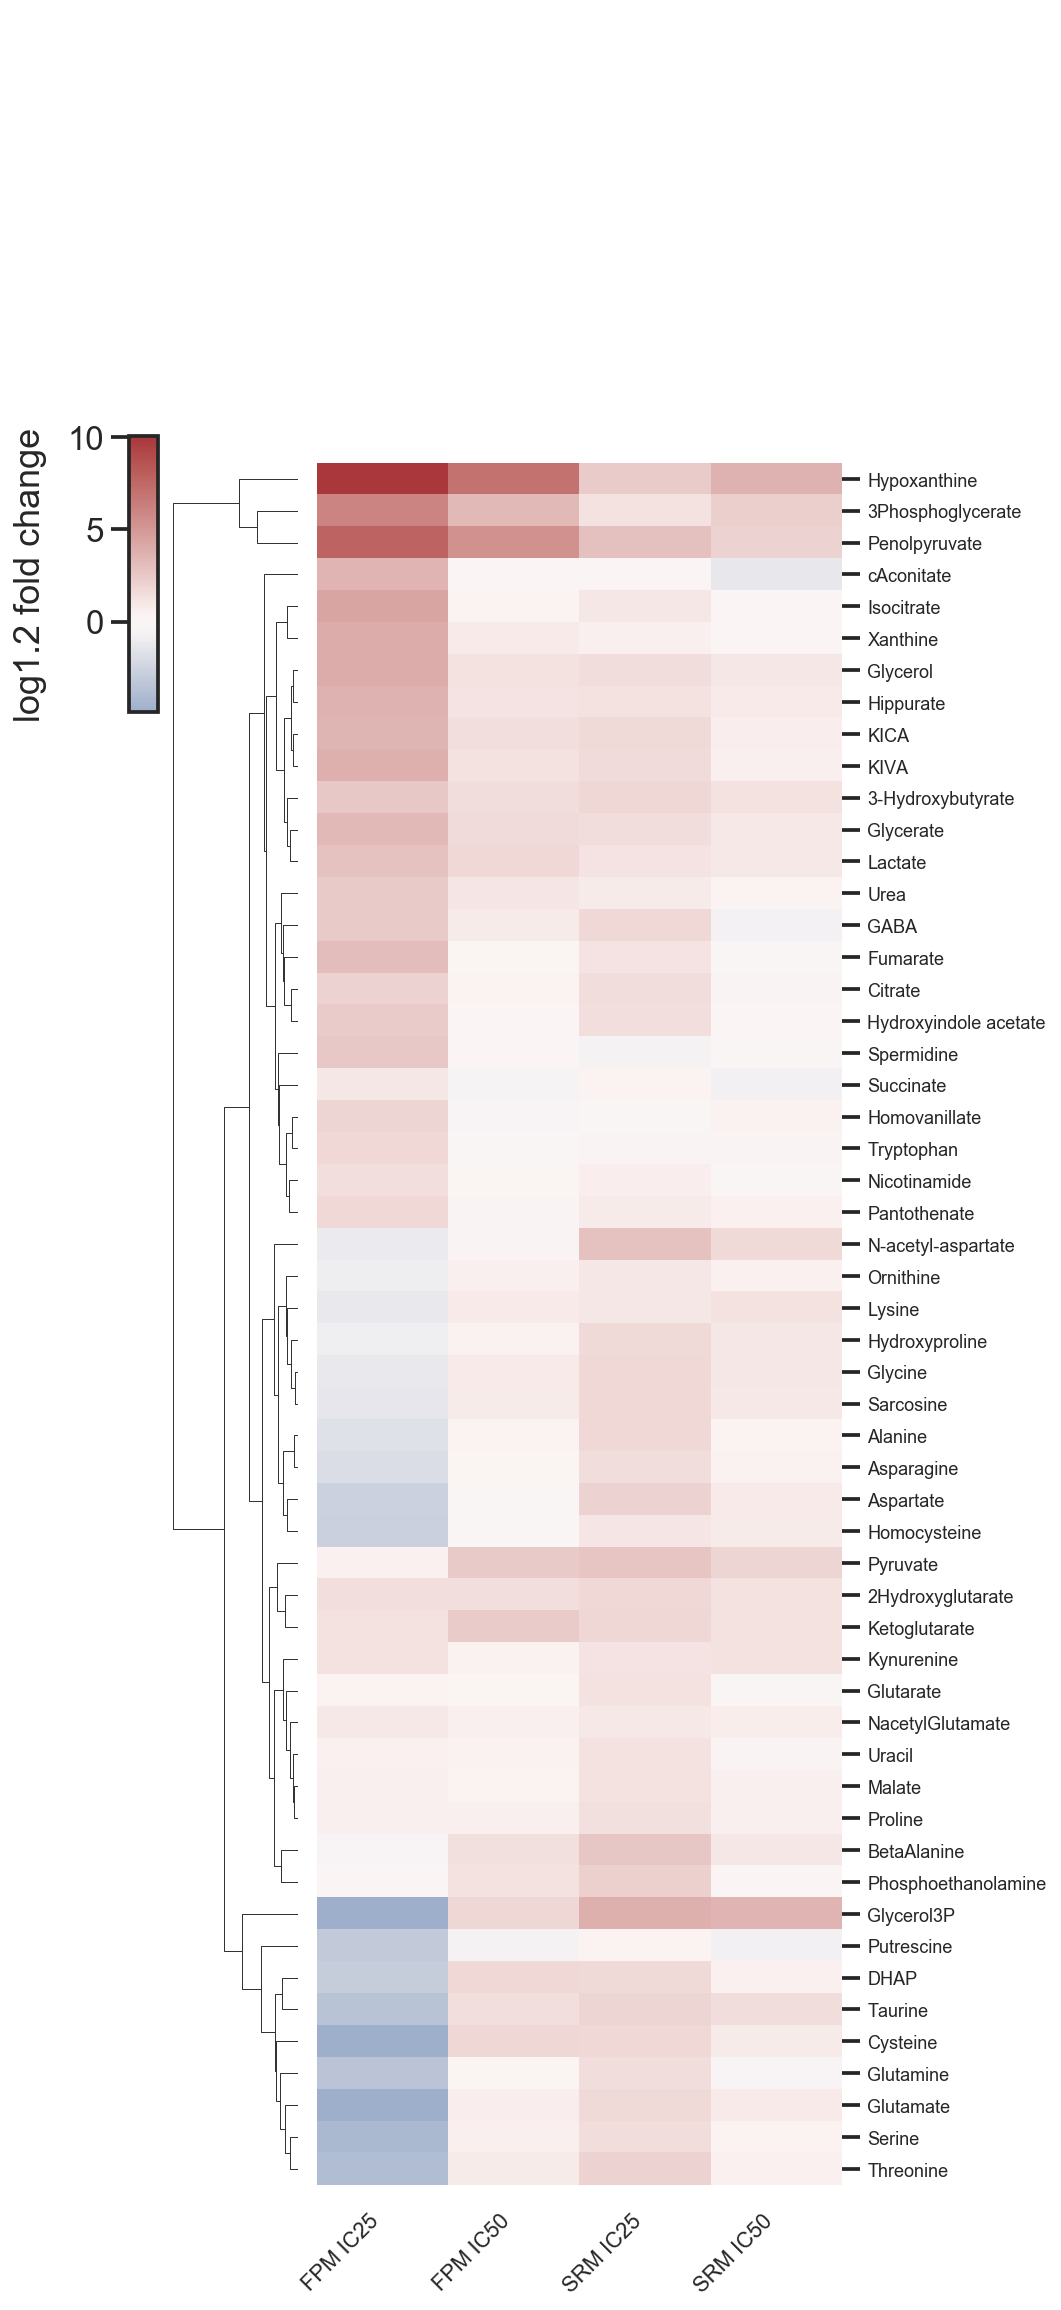

In [11]:
avg_clust = summary_df["Averages"].copy()
avg_clust = avg_clust.dropna(axis=0, how="any")

avg_fc_12 = (
    np.log(avg_clust.div(avg_clust["Control"], axis=0))
    / np.log(1.2)
)

avg_fc_plot_12 = avg_fc_12.drop("Control", axis=1)

rename_cols = {
    "FPM_low": "FPM IC25",
    "FPM_1.4": "FPM IC50",
    "SRM_low": "SRM IC25",
    "SRM_5.9": "SRM IC50",
}
avg_fc_plot_12 = avg_fc_plot_12.rename(columns=rename_cols)

# On log base 1.2 scale, ±1 = 1.2-fold
avg_fc_plot_12 = avg_fc_plot_12[
    avg_fc_plot_12.abs().max(axis=1) >= 1
]

g = sns.clustermap(
    avg_fc_plot_12,
    cmap="vlag",
    center=0,
    figsize=(8, 16),
    xticklabels=True,
    yticklabels=True,
    method="average",
    metric="euclidean",
    row_cluster=True,
    col_cluster=False,
    cbar_pos=None,
)

g.ax_heatmap.set_ylabel("")
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.tick_params(axis="y", labelsize=9)
g.ax_heatmap.tick_params(axis="x", labelsize=11)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(),
    rotation=45,
    ha="right",
)

cbar_ax = g.fig.add_axes([0.001, 0.68, 0.025, 0.12])
mappable = g.ax_heatmap.collections[0]
cbar = g.fig.colorbar(mappable, cax=cbar_ax)
cbar.set_label("log1.2 fold change", rotation=90, labelpad=10)
cbar_ax.yaxis.set_ticks_position("left")
cbar_ax.yaxis.set_label_position("left")

plt.show()

## 10. Replicated original analysis: top p/q hits after 1.2-fold gate

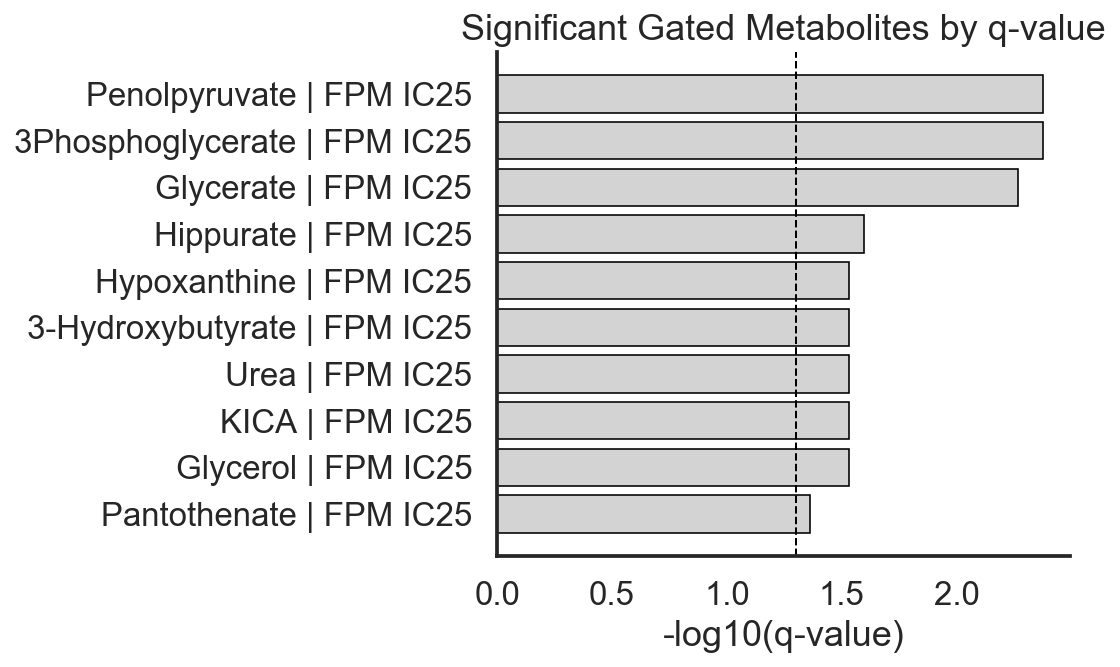

10 metabolite-treatment comparisons passed q < 0.05 and the 1.2-fold threshold.


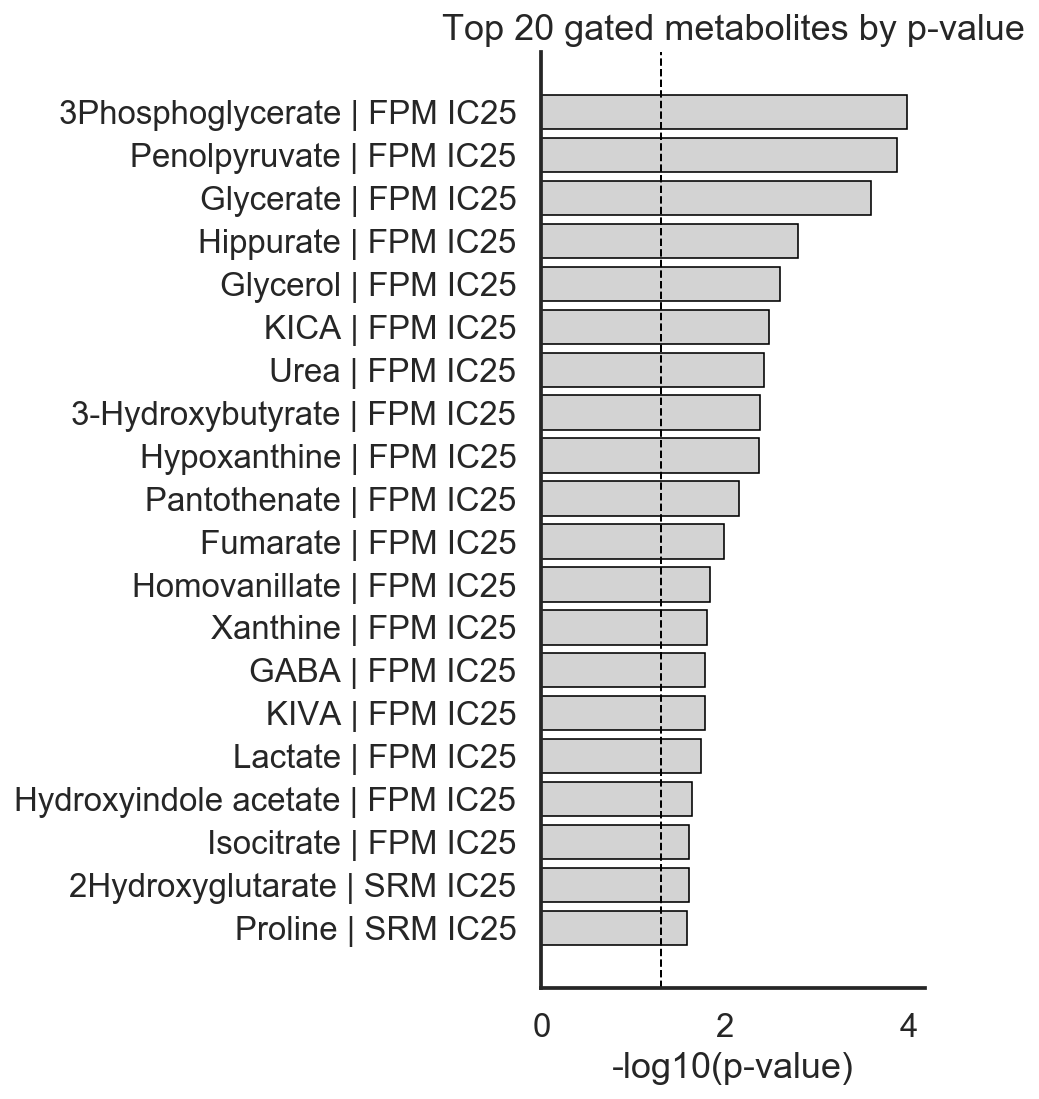

In [24]:
top_n = 20
epsilon_p = 1e-300

treatment_labels = {
    "FPM_low": "FPM IC25",
    "FPM_1.4": "FPM IC50",
    "SRM_low": "SRM IC25",
    "SRM_5.9": "SRM IC50",
}

plot_df = pairwise_df[
    pairwise_df["Treatment"].isin(treatment_labels)
].copy()

plot_df["Treatment_label"] = (
    plot_df["Treatment"]
    .map(treatment_labels)
    .fillna(plot_df["Treatment"])
)

fc_threshold = np.log2(1.2)

plot_df = plot_df[
    plot_df["log2FC"].abs() >= fc_threshold
].copy()

plot_df["neg_log10_qvalue"] = -np.log10(
    plot_df["qvalue"].clip(lower=epsilon_p)
)
plot_df["neg_log10_pvalue"] = -np.log10(
    plot_df["pvalue"].clip(lower=epsilon_p)
)
plot_df["Label"] = (
    plot_df["Metabolite"] + " | " + plot_df["Treatment_label"]
)

qvalue_threshold = 0.05
fc_threshold = np.log2(1.2)

# Keep only metabolites that pass both filters
significant_q = pairwise_df[
    (pairwise_df["qvalue"] < qvalue_threshold) &
    (pairwise_df["log2FC"].abs() >= fc_threshold)
].copy()

# Map treatment names
significant_q["Treatment_label"] = significant_q["Treatment"].map({
    "FPM_low": "FPM IC25",
    "FPM_1.4": "FPM IC50",
    "SRM_low": "SRM IC25",
    "SRM_5.9": "SRM IC50"
})

# Calculate plotting values
significant_q["neg_log10_qvalue"] = -np.log10(
    significant_q["qvalue"].clip(lower=1e-300)
)

significant_q["Label"] = (
    significant_q["Metabolite"] + " | " + significant_q["Treatment_label"]
)

# Sort so the smallest bar is at the bottom and largest at the top
significant_q = significant_q.sort_values(
    "neg_log10_qvalue",
    ascending=True
)

# Plot
fig, ax = plt.subplots(
    figsize=(8, max(5, len(significant_q) * 0.45))
)

ax.barh(
    significant_q["Label"],
    significant_q["neg_log10_qvalue"],
    color="lightgray",
    edgecolor="black",
    linewidth=0.8
)

# significance cutoff line
ax.axvline(
    -np.log10(0.05),
    color="black",
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("-log10(q-value)")
ax.set_ylabel("")
ax.set_title("Significant Gated Metabolites by q-value")

sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print(
    f"{len(significant_q)} metabolite-treatment comparisons passed "
    "q < 0.05 and the 1.2-fold threshold."
)
top_p = (
    plot_df
    .sort_values("pvalue", ascending=True)
    .head(top_n)
    .sort_values("neg_log10_pvalue", ascending=True)
)

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(
    top_p["Label"],
    top_p["neg_log10_pvalue"],
    color="lightgray",
    edgecolor="black",
    linewidth=0.8,
)
ax.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
ax.set_xlabel("-log10(p-value)")
ax.set_ylabel("")
ax.set_title(f"Top {top_n} gated metabolites by p-value")
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## 11. Replicated FPM-only analysis in long format

In [13]:
fpm_columns = (
    groups_stats["Control"]
    + groups_stats["FPM_low"]
    + groups_stats["FPM_1.4"]
)

fpm_df = (
    df_excluded[fpm_columns]
    .reset_index()
    .copy()
)

def get_treatment_label(col_name):
    if col_name in groups_stats["Control"]:
        return "Control"
    elif col_name in groups_stats["FPM_low"]:
        return "FPM IC25"
    elif col_name in groups_stats["FPM_1.4"]:
        return "FPM IC50"
    return "Other"

long_df = fpm_df.melt(
    id_vars="Metabolites",
    var_name="Sample",
    value_name="Abundance",
)

long_df["Treatment"] = long_df["Sample"].apply(get_treatment_label)
long_df = long_df[
    long_df["Treatment"].isin(["Control", "FPM IC25", "FPM IC50"])
].copy()

long_df["Treatment"] = pd.Categorical(
    long_df["Treatment"],
    categories=["Control", "FPM IC25", "FPM IC50"],
    ordered=True,
)

long_df["Abundance"] = pd.to_numeric(
    long_df["Abundance"],
    errors="coerce",
)

analysis_df = long_df.dropna(
    subset=["Metabolites", "Treatment", "Abundance"]
).copy()

display(analysis_df.head())

,Metabolites,Sample,Abundance,Treatment
0,2Aminobutyrate,Run1_Control_1,0.048421,Control
1,2Hydroxyglutarate,Run1_Control_1,0.027068,Control
2,3-Hydroxybutyrate,Run1_Control_1,0.021847,Control
3,3Phosphoglycerate,Run1_Control_1,0.570505,Control
4,Alanine,Run1_Control_1,7.396310,Control


## 12. Replicated original FPM analysis: top 10 by raw abundance difference

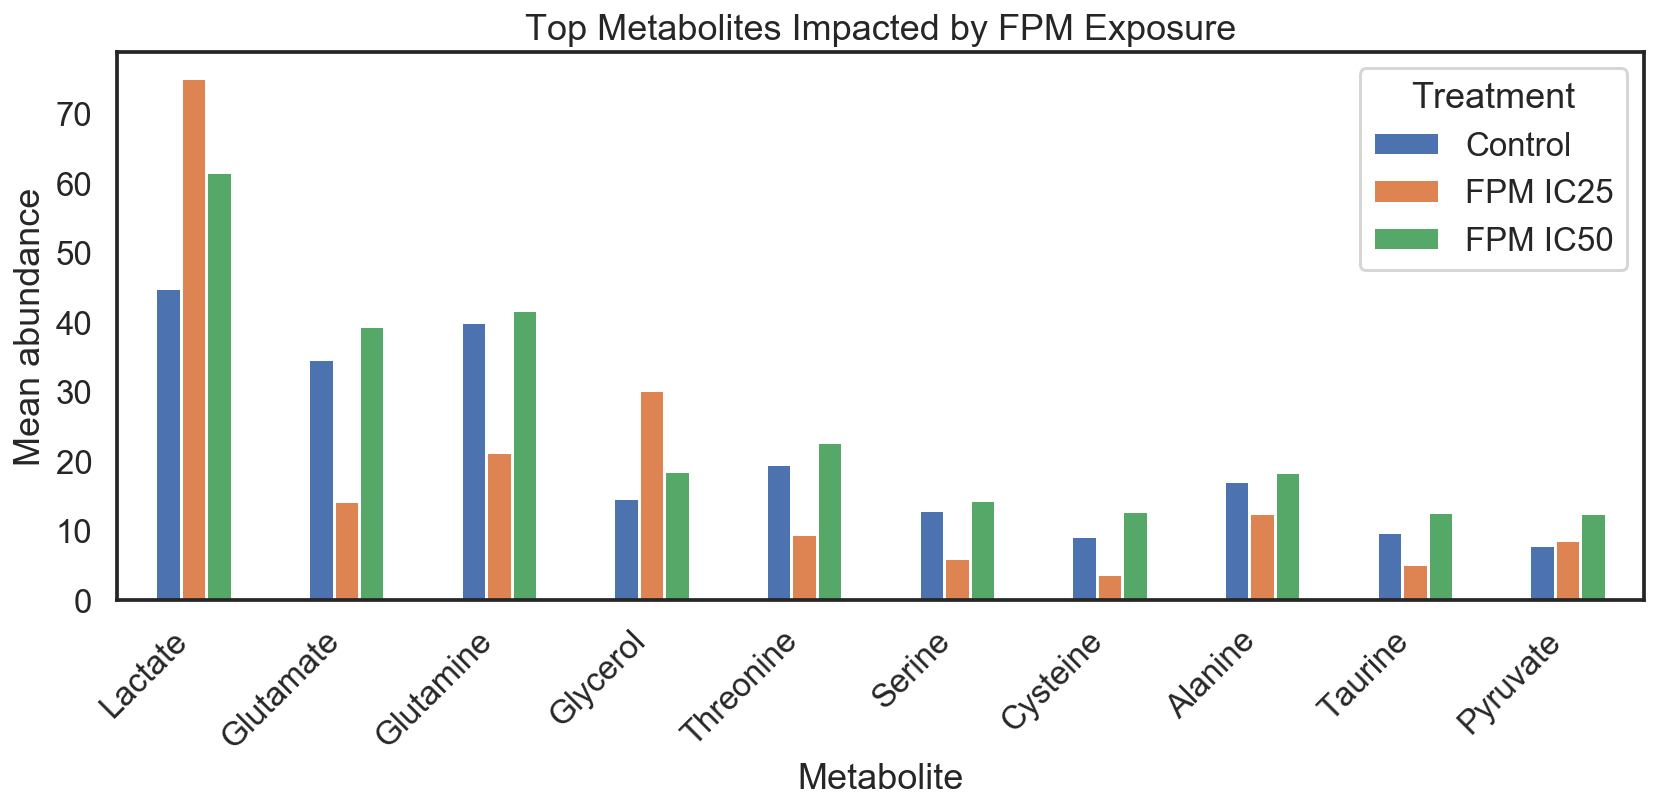

['Lactate', 'Glutamate', 'Glutamine', 'Glycerol', 'Threonine', 'Serine', 'Cysteine', 'Alanine', 'Taurine', 'Pyruvate']


In [14]:
mean_df = (
    analysis_df
    .groupby(["Metabolites", "Treatment"], observed=True)["Abundance"]
    .mean()
    .unstack()
)

mean_df.columns = pd.Index(mean_df.columns.astype(str))

ranking_df = mean_df.copy()
ranking_df["IC25_diff"] = ranking_df["FPM IC25"] - ranking_df["Control"]
ranking_df["IC50_diff"] = ranking_df["FPM IC50"] - ranking_df["Control"]
ranking_df["max_abs_diff"] = (
    ranking_df[["IC25_diff", "IC50_diff"]]
    .abs()
    .max(axis=1)
)

top_metabolites = (
    ranking_df
    .sort_values("max_abs_diff", ascending=False)
    .head(10)
    .index
    .tolist()
)

plot_summary = mean_df.loc[top_metabolites, [
    "Control", "FPM IC25", "FPM IC50"
]]

plot_summary.plot(
    kind="bar",
    figsize=(12, 6),
)

plt.ylabel("Mean abundance")
plt.xlabel("Metabolite")
plt.title("Top Metabolites Impacted by FPM Exposure")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(top_metabolites)

## 13. FPM log₂ fold-change table and 1.2-fold gate

In [15]:
# Use pairwise_df log2FC values to stay consistent with the statistical workflow
fpm_stats = pairwise_df[
    pairwise_df["Treatment"].isin(["FPM_low", "FPM_1.4"])
].copy()

fpm_stats["Treatment"] = fpm_stats["Treatment"].map({
    "FPM_low": "FPM IC25",
    "FPM_1.4": "FPM IC50",
})

log2fc_wide = fpm_stats.pivot(
    index="Metabolite",
    columns="Treatment",
    values="log2FC",
)

log2fc_wide.columns = pd.Index(log2fc_wide.columns.astype(str))

mean_table = mean_df.copy()
mean_table["FPM IC25 log2FC"] = log2fc_wide["FPM IC25"]
mean_table["FPM IC50 log2FC"] = log2fc_wide["FPM IC50"]

fold_change_threshold = 1.2
log2fc_threshold = np.log2(fold_change_threshold)

mean_table["Maximum absolute log2FC"] = (
    mean_table[["FPM IC25 log2FC", "FPM IC50 log2FC"]]
    .abs()
    .max(axis=1)
)

gated_metabolites = mean_table[
    mean_table["Maximum absolute log2FC"] >= log2fc_threshold
].copy()

print(
    f"{len(gated_metabolites)} metabolites passed "
    f"the {fold_change_threshold}-fold threshold."
)

display(
    gated_metabolites
    .sort_values("Maximum absolute log2FC", ascending=False)
    .head(20)
)

48 metabolites passed the 1.2-fold threshold.


Treatment,Control,FPM IC25,FPM IC50,FPM IC25 log2FC,FPM IC50 log2FC,Maximum absolute log2FC
Metabolites,,,,,,
Hypoxanthine,0.083890,0.527044,0.300908,2.651334,1.842733,2.651334
Penolpyruvate,0.119498,0.499919,0.316657,2.064697,1.405922,2.064697
3Phosphoglycerate,0.605715,1.830462,1.116371,1.595494,0.882104,1.595494
Cysteine,9.206893,3.770430,12.876375,-1.287985,0.483940,1.287985
Glutamate,34.741741,14.307209,39.491886,-1.279928,0.184886,1.279928
Glycerol3P,2.745352,1.135662,3.863213,-1.273457,0.492810,1.273457
Isocitrate,0.026402,0.058456,0.028132,1.146652,0.091539,1.146652
Serine,12.987723,6.102859,14.388761,-1.089591,0.147794,1.089591
Xanthine,0.089266,0.184385,0.106111,1.046526,0.249394,1.046526


## 14. Classify FPM metabolite changes

In [16]:
def classify_change(log2fc, threshold):
    if pd.isna(log2fc):
        return "Missing"
    if log2fc >= threshold:
        return "Increased"
    if log2fc <= -threshold:
        return "Decreased"
    return "Below threshold"

mean_table["IC25 classification"] = (
    mean_table["FPM IC25 log2FC"]
    .apply(classify_change, threshold=log2fc_threshold)
)

mean_table["IC50 classification"] = (
    mean_table["FPM IC50 log2FC"]
    .apply(classify_change, threshold=log2fc_threshold)
)

display(
    mean_table
    .sort_values("Maximum absolute log2FC", ascending=False)
    [
        [
            "Control",
            "FPM IC25",
            "FPM IC50",
            "FPM IC25 log2FC",
            "FPM IC50 log2FC",
            "Maximum absolute log2FC",
            "IC25 classification",
            "IC50 classification",
        ]
    ]
    .head(20)
)

Treatment,Control,FPM IC25,FPM IC50,FPM IC25 log2FC,FPM IC50 log2FC,Maximum absolute log2FC,IC25 classification,IC50 classification
Metabolites,,,,,,,,
Hypoxanthine,0.083890,0.527044,0.300908,2.651334,1.842733,2.651334,Increased,Increased
Penolpyruvate,0.119498,0.499919,0.316657,2.064697,1.405922,2.064697,Increased,Increased
3Phosphoglycerate,0.605715,1.830462,1.116371,1.595494,0.882104,1.595494,Increased,Increased
Cysteine,9.206893,3.770430,12.876375,-1.287985,0.483940,1.287985,Decreased,Increased
Glutamate,34.741741,14.307209,39.491886,-1.279928,0.184886,1.279928,Decreased,Below threshold
Glycerol3P,2.745352,1.135662,3.863213,-1.273457,0.492810,1.273457,Decreased,Increased
Isocitrate,0.026402,0.058456,0.028132,1.146652,0.091539,1.146652,Increased,Below threshold
Serine,12.987723,6.102859,14.388761,-1.089591,0.147794,1.089591,Decreased,Below threshold
Xanthine,0.089266,0.184385,0.106111,1.046526,0.249394,1.046526,Increased,Below threshold


## 15. Merge FPM p-values and q-values into the FPM summary table

In [17]:
fpm_stats_wide = fpm_stats.pivot(
    index="Metabolite",
    columns="Treatment",
    values=["pvalue", "qvalue"],
)

fpm_stats_wide.columns = [
    f"{treatment} {stat}"
    for stat, treatment in fpm_stats_wide.columns
]

mean_table = mean_table.join(
    fpm_stats_wide,
    how="left",
)

display(mean_table.head())

,Control,FPM IC25,FPM IC50,FPM IC25 log2FC,FPM IC50 log2FC,Maximum absolute log2FC,IC25 classification,IC50 classification,FPM IC25 pvalue,FPM IC50 pvalue,FPM IC25 qvalue,FPM IC50 qvalue
Metabolites,,,,,,,,,,,,
2Aminobutyrate,0.078643,0.068401,0.081391,-0.201303,0.049551,0.201303,Below threshold,Below threshold,0.523602,0.759027,0.636535,0.992067
2Hydroxyglutarate,0.039634,0.051399,0.051397,0.374994,0.374930,0.374994,Increased,Increased,0.072983,0.165651,0.205678,0.992067
3-Hydroxybutyrate,0.030397,0.048400,0.040389,0.671066,0.410027,0.671066,Increased,Increased,0.004173,0.065050,0.029476,0.992067
3Phosphoglycerate,0.605715,1.830462,1.116371,1.595494,0.882104,1.595494,Increased,Increased,0.000107,0.100447,0.004216,0.992067
Alanine,17.139648,12.504414,18.422220,-0.454900,0.104109,0.454900,Decreased,Below threshold,0.469894,0.670633,0.633336,0.992067


## 16. FPM metabolites passing 1.2-fold + raw p < 0.05

In [18]:
pvalue_threshold = 0.05

significant_table = mean_table[
    (
        (mean_table["FPM IC25 log2FC"].abs() >= log2fc_threshold)
        &
        (mean_table["FPM IC25 pvalue"] < pvalue_threshold)
    )
    |
    (
        (mean_table["FPM IC50 log2FC"].abs() >= log2fc_threshold)
        &
        (mean_table["FPM IC50 pvalue"] < pvalue_threshold)
    )
].copy()

significant_table = significant_table.sort_values(
    "Maximum absolute log2FC",
    ascending=True,
)

print(
    f"{len(significant_table)} metabolites passed the "
    "1.2-fold and p < 0.05 criteria."
)

display(significant_table)

21 metabolites passed the 1.2-fold and p < 0.05 criteria.


,Control,FPM IC25,FPM IC50,FPM IC25 log2FC,FPM IC50 log2FC,Maximum absolute log2FC,IC25 classification,IC50 classification,FPM IC25 pvalue,FPM IC50 pvalue,FPM IC25 qvalue,FPM IC50 qvalue
Metabolites,,,,,,,,,,,,
Pantothenate,0.530054,0.728663,0.559766,0.459113,0.078685,0.459113,Increased,Below threshold,0.007038,0.987072,0.043636,0.992067
Tryptophan,0.639258,0.890343,0.635310,0.477962,-0.008938,0.477962,Increased,Below threshold,0.037692,0.805944,0.122597,0.992067
Homovanillate,0.001576,0.002225,0.001497,0.497213,-0.073649,0.497213,Increased,Below threshold,0.014845,0.651448,0.069251,0.992067
Hydroxyindole acetate,0.010669,0.016463,0.010786,0.625724,0.015688,0.625724,Increased,Below threshold,0.022844,0.945303,0.083312,0.992067
Ketoglutarate,0.624297,0.789042,0.966680,0.337869,0.630805,0.630805,Increased,Increased,0.160390,0.049907,0.342902,0.992067
GABA,0.682550,1.060869,0.788777,0.636240,0.208683,0.636240,Increased,Below threshold,0.016534,0.655613,0.069251,0.992067
Urea,1.496186,2.360125,1.850679,0.657573,0.306765,0.657573,Increased,Increased,0.003835,0.582648,0.029476,0.992067
3-Hydroxybutyrate,0.030397,0.048400,0.040389,0.671066,0.410027,0.671066,Increased,Increased,0.004173,0.065050,0.029476,0.992067
Lactate,44.858465,75.134784,61.635602,0.744101,0.458384,0.744101,Increased,Increased,0.018346,0.287979,0.071089,0.992067


## 17. FPM p-filtered dot plot

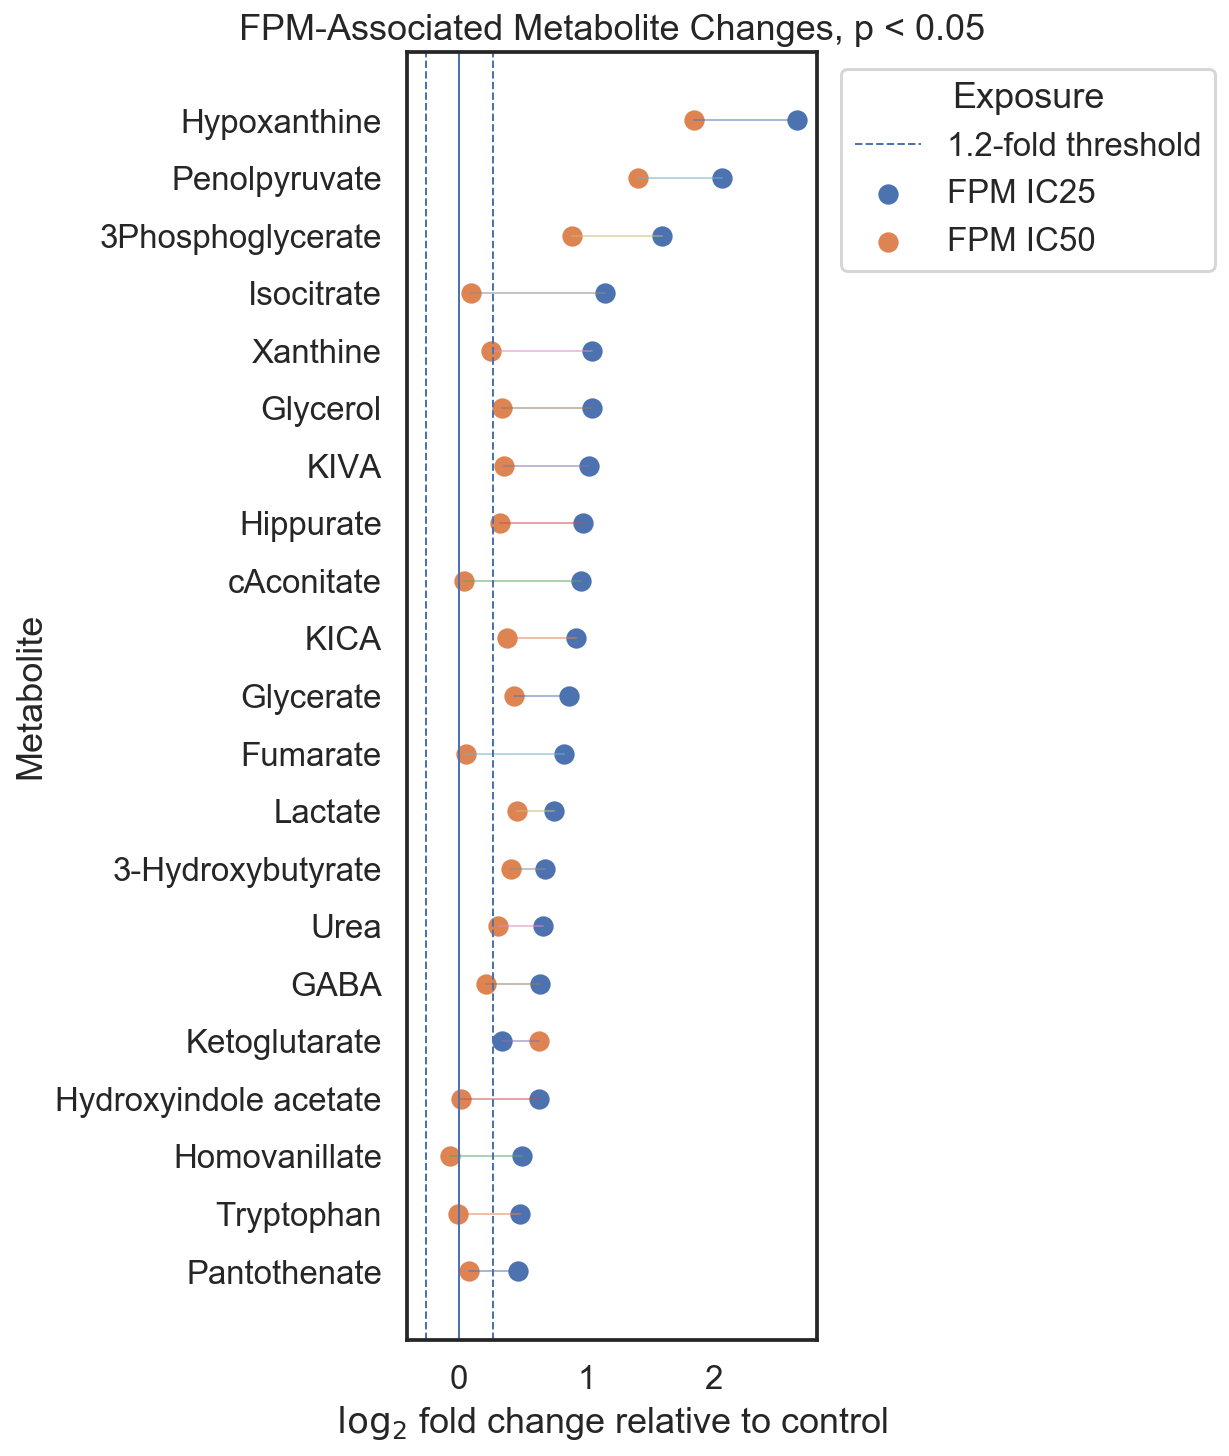

In [19]:
y_positions = np.arange(len(significant_table))
figure_height = max(5, len(significant_table) * 0.5)

plt.figure(figsize=(9, figure_height))

plt.scatter(
    significant_table["FPM IC25 log2FC"],
    y_positions,
    s=75,
    label="FPM IC25",
)

plt.scatter(
    significant_table["FPM IC50 log2FC"],
    y_positions,
    s=75,
    label="FPM IC50",
)

for y, ic25, ic50 in zip(
    y_positions,
    significant_table["FPM IC25 log2FC"],
    significant_table["FPM IC50 log2FC"],
):
    plt.plot(
        [ic25, ic50],
        [y, y],
        linewidth=1,
        alpha=0.5,
    )

plt.axvline(0, linewidth=1)
plt.axvline(
    log2fc_threshold,
    linestyle="--",
    linewidth=1,
    label="1.2-fold threshold",
)
plt.axvline(
    -log2fc_threshold,
    linestyle="--",
    linewidth=1,
)

plt.yticks(y_positions, significant_table.index)
plt.xlabel(r"$\log_2$ fold change relative to control")
plt.ylabel("Metabolite")
plt.title("FPM-Associated Metabolite Changes, p < 0.05")
plt.legend(
    title="Exposure",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)
plt.tight_layout()
plt.show()

## 18. Top 10 FPM metabolites passing the 1.2-fold threshold

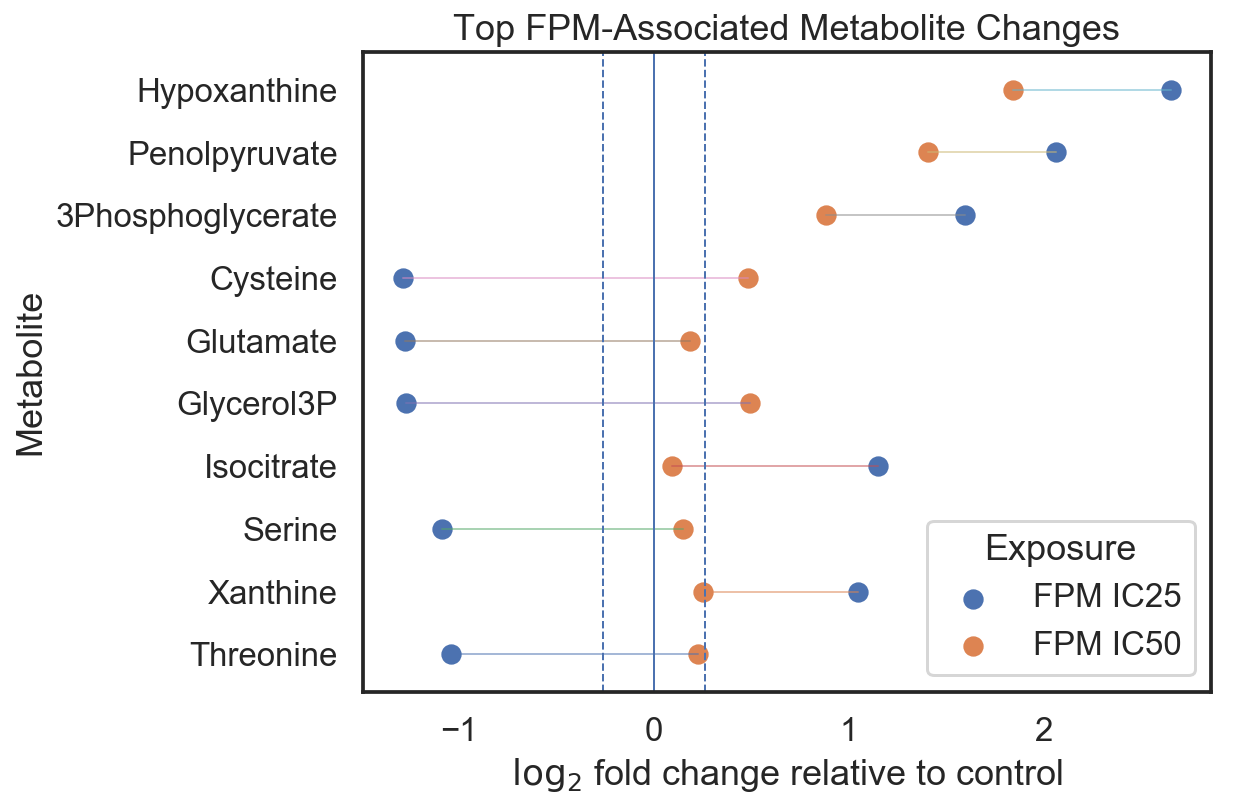

In [20]:
top_gated = (
    gated_metabolites
    .sort_values("Maximum absolute log2FC", ascending=False)
    .head(10)
    .sort_values("Maximum absolute log2FC", ascending=True)
)

y_positions = np.arange(len(top_gated))

plt.figure(figsize=(9, 6))

plt.scatter(
    top_gated["FPM IC25 log2FC"],
    y_positions,
    s=75,
    label="FPM IC25",
)

plt.scatter(
    top_gated["FPM IC50 log2FC"],
    y_positions,
    s=75,
    label="FPM IC50",
)

for y, ic25, ic50 in zip(
    y_positions,
    top_gated["FPM IC25 log2FC"],
    top_gated["FPM IC50 log2FC"],
):
    plt.plot([ic25, ic50], [y, y], linewidth=1, alpha=0.5)

plt.axvline(0, linewidth=1)
plt.axvline(log2fc_threshold, linestyle="--", linewidth=1)
plt.axvline(-log2fc_threshold, linestyle="--", linewidth=1)

plt.yticks(y_positions, top_gated.index)
plt.xlabel(r"$\log_2$ fold change relative to control")
plt.ylabel("Metabolite")
plt.title("Top FPM-Associated Metabolite Changes")
plt.legend(title="Exposure")
plt.tight_layout()
plt.show()

## 19. Final landscape FPM plot — all metabolites passing 1.2-fold, no p/q filter

48 shared metabolites pass the 1.2-fold threshold.


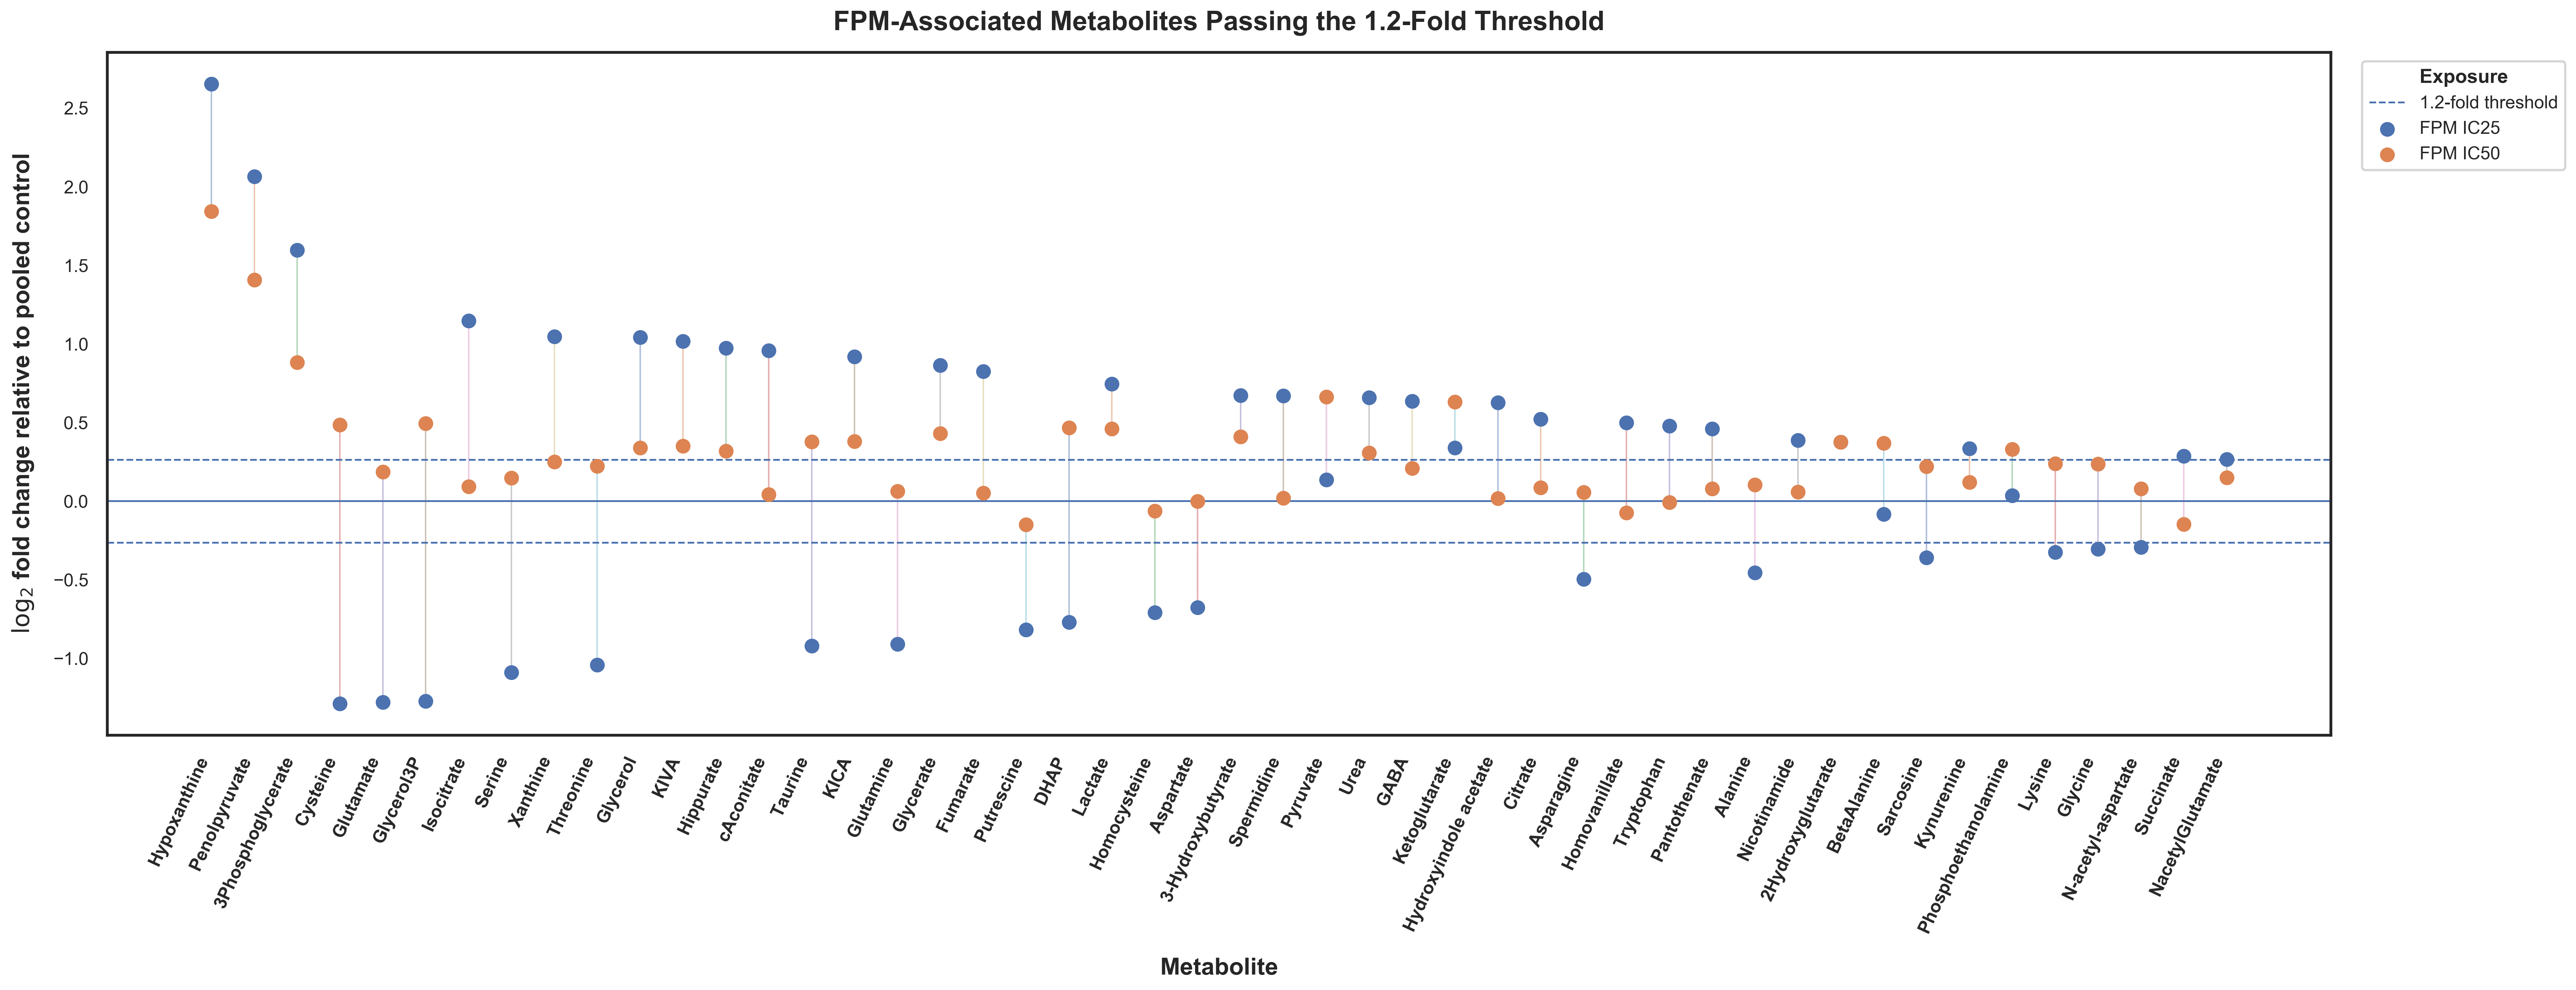

In [21]:
plot_stats = pairwise_df[
    pairwise_df["Treatment"].isin(["FPM_low", "FPM_1.4"])
].copy()

plot_stats["Treatment"] = plot_stats["Treatment"].map({
    "FPM_low": "FPM IC25",
    "FPM_1.4": "FPM IC50",
})

plot_table = plot_stats.pivot(
    index="Metabolite",
    columns="Treatment",
    values="log2FC",
)

plot_table.columns = pd.Index(plot_table.columns.astype(str))

plot_table = plot_table[
    (plot_table["FPM IC25"].abs() >= log2fc_threshold)
    |
    (plot_table["FPM IC50"].abs() >= log2fc_threshold)
].copy()

plot_table["Maximum absolute log2FC"] = (
    plot_table[["FPM IC25", "FPM IC50"]]
    .abs()
    .max(axis=1)
)

plot_table = plot_table.sort_values(
    "Maximum absolute log2FC",
    ascending=False,
)

print(
    f"{len(plot_table)} shared metabolites pass the "
    f"{fold_change_threshold}-fold threshold."
)

x = np.arange(len(plot_table))

fig, ax = plt.subplots(
    figsize=(26, 10),
    dpi=150,
)

ax.scatter(
    x,
    plot_table["FPM IC25"],
    s=70,
    label="FPM IC25",
    zorder=3,
)

ax.scatter(
    x,
    plot_table["FPM IC50"],
    s=70,
    label="FPM IC50",
    zorder=3,
)

for i, (ic25, ic50) in enumerate(
    zip(plot_table["FPM IC25"], plot_table["FPM IC50"])
):
    if pd.notna(ic25) and pd.notna(ic50):
        ax.plot(
            [i, i],
            [ic25, ic50],
            linewidth=1,
            alpha=0.45,
            zorder=2,
        )

ax.axhline(0, linewidth=1.2)
ax.axhline(
    log2fc_threshold,
    linestyle="--",
    linewidth=1.2,
    label="1.2-fold threshold",
)
ax.axhline(
    -log2fc_threshold,
    linestyle="--",
    linewidth=1.2,
)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_table.index,
    rotation=65,
    ha="right",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel(
    "Metabolite",
    fontsize=16,
    fontweight="bold",
    labelpad=15,
)

ax.set_ylabel(
    r"$\log_2$ fold change relative to pooled control",
    fontsize=16,
    fontweight="bold",
    labelpad=12,
)

ax.set_title(
    "FPM-Associated Metabolites Passing the 1.2-Fold Threshold",
    fontsize=18,
    fontweight="bold",
    pad=15,
)

ax.tick_params(axis="y", labelsize=12)

legend = ax.legend(
    title="Exposure",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=12,
    title_fontsize=13,
)
legend.get_title().set_fontweight("bold")

plt.tight_layout()
plt.subplots_adjust(bottom=0.30, right=0.84)
plt.show()

## 20. Run-specific metabolites

In [22]:
run1_unique_df = run1.loc[run1_only_metabolites].copy()
run2_unique_df = run2.loc[run2_only_metabolites].copy()

print("Run 1-only metabolites:")
display(run1_unique_df)

print("Run 2-only metabolites:")
display(run2_unique_df)

Run 1-only metabolites:


,Run1_Control_1,Run1_Control_2,Run1_Control_3,Run1_FPM_IC25_1,Run1_FPM_IC25_2,Run1_FPM_IC25_3,Run1_FPM_IC50_1,Run1_FPM_IC50_2,Run1_SRM_IC25_1,Run1_SRM_IC25_2,Run1_SRM_IC50_1,Run1_SRM_IC50_2
Metabolites,,,,,,,,,,,,
4OHBenzoate,0.003359,0.002732,0.002918,0.005182,0.004144,0.003505,0.006781,0.004118,0.003471,0.00268,0.004434,0.003171


Run 2-only metabolites:


,Run2_Control_1,Run2_FPM_IC50_1,Run2_SRM_IC25_1,Run2_SRM_IC50_1,Run2_Control_2,Run2_FPM_IC50_2,Run2_SRM_IC25_2,Run2_SRM_IC50_2,Run2_Control_3,Run2_FPM_IC50_3,Run2_SRM_IC25_3,Run2_SRM_IC50_3
Cystine,0.044105,0.055920,0.048565,0.099974,0.037762,0.078275,0.049321,0.049921,0.047100,0.050681,0.089883,0.070103
Histidine,0.873854,0.647268,1.545432,1.213162,1.150150,1.356442,1.046590,0.502800,1.102961,1.105393,1.307171,1.902567
Quinolinate,0.004299,0.003200,0.003523,0.003655,0.003674,0.005927,0.005151,0.004300,0.002940,0.004260,0.003261,0.004421
Serotonin,3.536616,1.671925,5.506717,3.905485,3.971342,2.965651,3.311231,1.533596,3.272955,4.536267,3.914276,7.389138


## 21. Export combined analysis tables

In [23]:
combined_all.reset_index().to_csv(
    "combined_gc_ms_nmols_harmonized.csv",
    index=False,
)

pooled_df.reset_index().to_csv(
    "combined_gc_ms_shared_metabolites.csv",
    index=False,
)

sample_metadata.to_csv(
    "combined_gc_ms_sample_metadata.csv",
    index=False,
)

pairwise_df.to_csv(
    "combined_gc_ms_pairwise_results.csv",
    index=False,
)

cell_qc.to_csv(
    "gc_ms_cell_count_qc.csv",
    index=False,
)

technical_qc.to_csv(
    "gc_ms_technical_replicate_qc.csv",
    index=False,
)

print("Exported combined analysis tables.")

Exported combined analysis tables.
